# Pairwise overdamped-with-memory inference on MDCK tracks (corrected loss)

Implements Method.pdf Sec. II and SI VI: cells follow Eq. (9),

$\dot v_i = F^{\rm int}_i + H_i + \gamma'_{{\rm eff},i}\cdot v_i + \xi$, with $\gamma'_{{\rm eff},i} = \tau\sum_j M_{ij} - I/\tau$ and $H_i = -\tau\sum_j M_{ij} v_j$,

where the pair force $f(r)\,\hat r_{ij}$ is an MLP and $\tau$ a learned scalar (trained as $\log\tau$).
Derivatives come from a gap-aware Savitzky–Golay filter. The loss is Eq. (54):

$L = \langle(\hat{\dot v} - D_\theta)^2\rangle + 2K_{av}\sigma^2\langle\partial D_{i\mu}/\partial v_{i\mu}\rangle - V_{\rm loc}(\theta)$ (+ far-field penalty),

with $\sigma^2$ re-estimated from the residual (Eq. 55) and $\Lambda$ from raw increments. The
measurement-noise term $V_{\rm loc}$ is switched with `correct_measurement_noise`; for the first
`warmup_epochs` only the MSE (+ far-field penalty) is minimised.

Units: microns and hours. The inferred pair force is $F^{\rm int}/(\gamma\tau)$ in µm h⁻².

In [76]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import inference_helpers_simple as gc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters

In [77]:
datadir  = "/Users/billiemeadowcroft/Dropbox/PostDocCode/Github_SFI/Billie_Inference_Pytorch/Loss-With-Noise-Inference/MDCK_Data_CSV/"
datasave = "/Users/billiemeadowcroft/Dropbox/PostDocCode/Github_SFI/Billie_Inference_Pytorch/Loss-With-Noise-Inference/models/"
dataname = "20260515_wt_mdck_65hr_postHGF_s55_Tracks.csv"
frame_lo, frame_hi = 0,80 #110, 260      # keep min_frame + frame_lo < frame < min_frame + frame_hi

dt              = 0.167            # h per frame
pixel_to_micron = 0.622            # um per pixel
r_cut           = 120.0            # um, neighbour cutoff
edge_margin     = 20.0             # um, nodes this close to the FOV edge are left out of the loss

sg_window, sg_poly, sg_S = 7, 3, 1 # S-G window, degree, velocity shift

correct_measurement_noise = False   # V_loc term (Method.pdf Eq. 54) on/off

tau_init      = 0.7                # h
hidden_dim    = 64
num_epochs    = 200
warmup_epochs = 50                 # plain-MSE epochs before the correction switches on
phi_sg_in_warmup = True            # during warmup multiply the drag by Phi_SG (149/378 for 9, 3, S=1)
learning_rate = 1e-3
sigma2_every  = 10                 # epochs between sigma^2 re-estimates (Method.pdf SI VI A 3)
sigma2_momentum = 0.8              # EMA weight on the previous sigma^2 at each re-estimate
                                   # (0 = replace with the new estimate)
n_probes_Vloc = 2                  # Hutchinson probes per step for V_loc

# Far-field penalty, as in torch_notebook_OldWtFarField.ipynb (reg = 0 switches it off)
far_field = dict(reg=1000.0, r_min=100.0, r_max=120.0, K=1000, seed=1)

split_seed, init_seed = 1234, 5070

## Model

`forward` rebuilds $r_{ij}$ and $\hat r_{ij}$ from the (normalised) positions, so the same function is
trained and differentiated for the localization-noise Jacobians. Inputs: normalised positions,
physical velocities [µm/h], edges `[source j, target i]`. Output: $D_i/y_{\rm std}$ and, if asked,
${\rm Tr}\,\gamma'_{{\rm eff},i}/y_{\rm std}$ (the only velocity dependence on $v_i$, Method.pdf Eq. 44–45).
`drag_scale` multiplies the drag part $(-v_i/\tau + \tau\sum_j M_{ij} v_i)$: it is $\Phi_{SG}$ during warmup if
`phi_sg_in_warmup` (Method.pdf App. A 4–5), and 1 once the additive correction is on.

In [78]:
class ForceGNN(nn.Module):
    def __init__(self, hidden_dim=64, tau_init=1.0):
        super().__init__()
        self.interaction_net = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 1))
        self.log_tau = nn.Parameter(torch.log(torch.tensor(float(tau_init))))
        self.drag_scale = 1.0      # multiplies the drag part; Phi_SG during warmup (train_model)
        self.x_std = self.r_std = self.y_std = 1.0

    def set_normalisation(self, norm):
        self.x_std, self.r_std, self.y_std = float(norm['x_std']), float(norm['r_std']), float(norm['y_std'])

    @property
    def tau(self):
        return torch.exp(self.log_tau)

    def pair_force(self, r):
        # f(r) and df/dr, both in normalised units (r = r_phys / r_std, f = f_phys / y_std)
        return torch.func.jvp(self.interaction_net, (r,), (torch.ones_like(r),))

    def forward(self, pos, vel, edges, return_trace=False):
        N, tau = pos.shape[0], self.tau
        drag = -(1.0 / tau) * vel / self.y_std                  # gamma'_eff . v_i  (drag part)
        force = torch.zeros_like(drag)                           # F_int + H
        trace = (-2.0 / (tau * self.y_std)) * torch.ones(N, dtype=pos.dtype)
        if edges.shape[1] > 0:
            j, i = edges[0].long(), edges[1].long()
            d = pos[i] - pos[j]                                  # x_i - x_j (x_std units)
            r_x = d.norm(dim=1, keepdim=True).clamp(min=1e-8)
            unit = d / r_x                                       # r_hat_ij
            r = r_x * (self.x_std / self.r_std)                  # r_ij / r_std
            f, dfdr = self.pair_force(r)
            c = tau / self.r_std                                 # tau * (1/r_std from d/dr_phys and 1/r_phys)

            def Mv(w):                                           # tau * M_ij . w   (Method.pdf Eq. 6)
                rw = (unit * w).sum(1, keepdim=True)
                return c * (dfdr * rw * unit + (f / r) * (w - unit * rw))

            drag = drag.index_add(0, i, Mv(vel[i]))
            force = force.index_add(0, i, f * unit - Mv(vel[j]))
            if return_trace:
                trace = trace.index_add(0, i, (c * (dfdr + f / r)).squeeze(1))
        D = self.drag_scale * drag + force
        return (D, self.drag_scale * trace) if return_trace else D


def get_forces(model, r_phys):
    # Learned pair force f(r)/(gamma*tau) [um/h^2] at physical distances r_phys [um]
    r = torch.as_tensor(np.asarray(r_phys, dtype=np.float32) / model.r_std).reshape(-1, 1)
    with torch.no_grad():
        return model.y_std * model.interaction_net(r).squeeze(1).numpy()


def tensors(dp):
    # Cached torch views of one frame: pos (normalised), vel (physical), edges, targets, mask
    if '_t' not in dp:
        n = torch.as_tensor(dp['nodes'])
        dp['_t'] = (n[:, :2], n[:, 2:4], torch.as_tensor(dp['edges']),
                    torch.as_tensor(dp['targets']), torch.as_tensor(dp['mask']))
    return dp['_t']

## Loss terms

`frame_terms` returns, for one frame (averages over nodes in the loss and over components):
MSE, the dynamical-noise term $K_{av}\sigma^2\,{\rm Tr}\gamma'$ (= $2K_{av}\sigma^2\langle\partial D_{i\mu}/\partial v_{i\mu}\rangle$ in 2D),
and $V_{\rm loc}$ (Method.pdf Eq. 52, Hutchinson estimate; $J_x$, $J_v$ via `torch.func.jvp`). All in
normalised units ($\sigma^2$ is $\sigma^2_{\rm phys}/y_{\rm std}^2$). `noise` holds `kav, kaa, dt, stencils, Lambda, n_probes, correct`.

In [79]:
def jvp_Jx_Jv(model, pos, vel, edges, z):
    # Physical J_x.z and J_v.z of D_phys for a probe z
    _, jx = torch.func.jvp(lambda p: model(p, vel, edges), (pos,), (z,))
    _, jv = torch.func.jvp(lambda v: model(pos, v, edges), (vel,), (z,))
    return (model.y_std / model.x_std) * jx, model.y_std * jv


def localization_variance(model, pos, vel, edges, w, noise):
    # V_loc [physical accel^2]; average over nodes i uses the loss mask w, the sum over
    # neighbours j (inside J_x.z, J_v.z) includes every node.
    ca, qa, cv, qv, c0, q0 = noise['stencils']
    la, lv, l0 = dict(zip(qa, ca)), dict(zip(qv, cv)), dict(zip(q0, c0))
    offsets = sorted(set(qa) | set(qv) | set(q0))
    dt, n = noise['dt'], w.sum()
    acc = pos.new_zeros(())
    for _ in range(noise['n_probes']):
        z = torch.randint(0, 2, pos.shape).to(pos.dtype) * 2 - 1
        Jx_z, Jv_z = jvp_Jx_Jv(model, pos, vel, edges, z)
        for q in offsets:
            R = (la.get(q, 0.0) / dt ** 2) * z - l0.get(q, 0.0) * Jx_z - (lv.get(q, 0.0) / dt) * Jv_z
            acc = acc + ((R ** 2).sum(1) * w).sum() / n
    return noise['Lambda'] * acc / (noise['n_probes'] * 2.0)


def frame_terms(model, dp, sigma2, noise, with_loc):
    pos, vel, edges, targ, w = tensors(dp)
    n = w.sum()
    pred, trace = model(pos, vel, edges, return_trace=True)
    mse = (((pred - targ) ** 2).sum(1) * w).sum() / (2.0 * n)
    dyn = noise['kav'] * sigma2 * model.y_std * (trace * w).sum() / n if sigma2 is not None else mse.new_zeros(())
    loc = (localization_variance(model, pos, vel, edges, w, noise) / model.y_std ** 2
           if with_loc else mse.new_zeros(()))
    return dict(mse=mse, dyn=dyn, loc=loc, objective=mse + dyn - loc, n=n.item())


def dataset_terms(model, data, sigma2, noise, with_loc):
    # Node-weighted averages of frame_terms over a list of frames (no parameter update)
    tot, N = dict(mse=0.0, dyn=0.0, loc=0.0, objective=0.0), 0.0
    model.eval()
    with (torch.enable_grad() if with_loc else torch.no_grad()):
        for dp in data:
            if dp['mask'].sum() == 0:
                continue
            t = frame_terms(model, dp, sigma2, noise, with_loc)
            for k in tot:
                tot[k] += float(t[k].detach()) * t['n']
            N += t['n']
    return {k: v / N for k, v in tot.items()}


def estimate_sigma2(model, train_data, noise):
    # Method.pdf Eq. (55), normalised units: (dt/K_aa) * (<resid^2> - V_loc/y_std^2)
    t = dataset_terms(model, train_data, None, noise, with_loc=noise['correct'])
    s2 = (noise['dt'] / noise['kaa']) * (t['mse'] - t['loc'])
    if s2 <= 0:
        print(f"  WARNING: sigma^2 estimate {s2:.4g} <= 0 (mse={t['mse']:.4g}, V_loc={t['loc']:.4g})")
    return s2


def far_field_penalty(model, r_far, far_field):
    if far_field['reg'] == 0:
        return torch.zeros(())
    return far_field['reg'] * model.interaction_net(r_far / model.r_std).pow(2).mean()

## Training

Adam, one step per frame. For `epoch < warmup_epochs` the objective is the MSE (+ far-field penalty),
with the drag multiplied by $\Phi_{SG}$ if `phi_sg_in_warmup`;
from `warmup_epochs` on, $\sigma^2$ is estimated (then every `sigma2_every` epochs) and the corrected loss is used.
Each re-estimate after the first is blended as $\sigma^2 \leftarrow m\,\sigma^2 + (1-m)\,\hat\sigma^2_{\rm new}$ with $m$ = `sigma2_momentum`, and $\sigma^2$ is clamped at 0.
History: per-epoch MSE and full objective for train (averaged over the training pass) and validation.

In [80]:
def train_model(model, train_data, val_data, noise, num_epochs, warmup_epochs, learning_rate,
                sigma2_every=25, sigma2_momentum=0.0, phi_warmup=1.0, far_field=None, print_every=10):
    # phi_warmup: drag factor during warmup (Phi_SG, or 1.0 for none); 1.0 afterwards.
    far_field = far_field or dict(reg=0.0)
    opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
    sigma2 = None
    hist = {k: [] for k in ('train_mse', 'train_objective', 'val_mse', 'val_objective', 'tau', 'sigma2')}

    for epoch in range(num_epochs):
        model.drag_scale = phi_warmup if epoch < warmup_epochs else 1.0
        if epoch >= warmup_epochs and (sigma2 is None or (epoch - warmup_epochs) % sigma2_every == 0):
            s2_new = estimate_sigma2(model, train_data, noise)
            # First estimate (end of warmup) is used as is; later ones are blended with the
            # current value: sigma2 <- m*sigma2 + (1-m)*s2_new. Clamped at 0 (a variance).
            sigma2 = s2_new if sigma2 is None else sigma2_momentum * sigma2 + (1.0 - sigma2_momentum) * s2_new
            sigma2 = max(0.0, sigma2)
            print(f"  [epoch {epoch}] sigma^2 = {sigma2:.5f} (new estimate {s2_new:.5f}, normalised)")
        with_loc = noise['correct'] and sigma2 is not None

        r_far = None
        if far_field['reg'] != 0:
            g = torch.Generator().manual_seed(far_field['seed'] + epoch)
            r_far = far_field['r_min'] + (far_field['r_max'] - far_field['r_min']) * torch.rand(far_field['K'], 1, generator=g)

        model.train()
        s_mse = s_obj = s_n = 0.0
        for dp in train_data:
            if dp['mask'].sum() == 0:
                continue
            t = frame_terms(model, dp, sigma2, noise, with_loc)
            loss = t['objective'] + (far_field_penalty(model, r_far, far_field) if r_far is not None else 0.0)
            opt.zero_grad()
            loss.backward()
            opt.step()
            s_mse += t['mse'].item() * t['n']; s_obj += float(loss) * t['n']; s_n += t['n']

        v = dataset_terms(model, val_data, sigma2, noise, with_loc)
        hist['train_mse'].append(s_mse / s_n); hist['train_objective'].append(s_obj / s_n)
        hist['val_mse'].append(v['mse']);      hist['val_objective'].append(v['objective'])
        hist['tau'].append(model.tau.item());  hist['sigma2'].append(np.nan if sigma2 is None else sigma2)

        if epoch % print_every == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch:4d} | train mse {hist['train_mse'][-1]:.5f} obj {hist['train_objective'][-1]:.5f} | "
                  f"val mse {v['mse']:.5f} obj {v['objective']:.5f} (dyn {v['dyn']:.4f}, loc {v['loc']:.4f}) | "
                  f"tau {hist['tau'][-1]:.4f} h")
    model.drag_scale = 1.0
    return model, hist

## Data

In [81]:
data = gc.load_data(datadir, dataname)
f0 = data['frame'].min()
data = data[(data['frame'] > f0 + frame_lo) & (data['frame'] < f0 + frame_hi)].copy()
data['x'] = (data['x'] - data['x'].mean()) * pixel_to_micron      # pixels -> microns
data['y'] = (data['y'] - data['y'].mean()) * pixel_to_micron
fov_bounds = (data['x'].min(), data['x'].max(), data['y'].min(), data['y'].max())

data_clean = gc.calculate_derivatives_sg(data, dt=dt, m=(sg_window - 1) // 2, p=sg_poly, S=sg_S)
Lambda_hat = gc.estimate_lambda(data_clean, dt)
print(f"Lambda_hat = {Lambda_hat:.5f} um^2  (sqrt = {np.sqrt(Lambda_hat):.4f} um)")

dataset, norm = gc.prepare_dataset(data_clean, cutoff=r_cut, edge_margin=edge_margin, fov_bounds=fov_bounds)
train_data, val_data, test_data = gc.split_dataset(dataset, seed=split_seed)

ca, qa, cv, qv = gc.sg_stencils(sg_window, sg_poly, sg_S)
c0, q0 = gc.sg_position_stencil(sg_window, sg_poly)
noise = dict(kav=gc.Kav(ca, qa, cv, qv), kaa=gc.Kaa(ca, qa), dt=dt,
             stencils=(ca, qa, cv, qv, c0, q0), Lambda=Lambda_hat,
             n_probes=n_probes_Vloc, correct=correct_measurement_noise)
phi_value = gc.phi_factor(ca, qa, cv, qv)
print(f"K_av = {noise['kav']:.6f}, K_aa = {noise['kaa']:.6f}, Phi_SG = {phi_value:.6f}")

Data loaded: (180211, 4), columns ['frame', 'particle', 'x', 'y'], 391 frames
S-G derivatives (window=7, p=3, S=1): 584 contiguous segments (115 shorter than the window, kept as neighbour-only); valid frames 21360, neighbour-only frames 3670; ax std (valid) = 10.4696
Lambda_hat = 0.40083 um^2  (sqrt = 0.6331 um)
Dataset: 79 frames, 25030 nodes, 19207 in the loss (76.7%); edge mask 20.0 from FOV x=[-304.3, 418.1], y=[-473.1, 537.5]
  max r = 120.00, x_std = 346.9389, r_std = 28.4800, y_std = 9.7104
Split: train 55, val 11, test 13 frames
K_av = 0.247732, K_aa = 0.213152, Phi_SG = 0.504535


### Choosing the S-G window: residual autocorrelation (Method.pdf SI VI D, Fig. 6b)

For each window $w$ in `windows` (degree `sg_poly`), every contiguous track segment is smoothed and the
residual $x_{\rm raw} - x_{\rm smooth}$ is taken (both components). The ACF is pooled over all segments,
$C(k) = \langle r_t\,r_{t+k}\rangle / \langle r_t^2\rangle$, using only pairs within the same segment. A window that is too
narrow leaves dynamical signal in the residual; one that is too wide leaves correlated structure from
over-smoothing. Pick the window whose residual ACF is closest to zero at all lags $\geq 1$; the printed score is
$\sum_{k=1}^{k_{\max}} |C(k)|$ (lower is better). Segments shorter than the largest window are skipped, so every
window is scored on the same data.

w =   5: sum_k>=1 |ACF| = 1.419
w =   7: sum_k>=1 |ACF| = 1.199
w =   9: sum_k>=1 |ACF| = 1.136
w =  11: sum_k>=1 |ACF| = 1.130
Most uncorrelated residual: w = 11


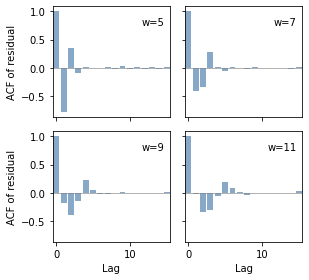

In [82]:
from scipy.signal import savgol_filter

windows = [5, 7, 9, 11]     # odd, > sg_poly
max_lag = 15


def residual_acf(data, window, poly, max_lag, min_len):
    num, den = np.zeros(max_lag + 1), np.zeros(max_lag + 1)
    for seg in gc._segments(data, gc._frame_step(data)):
        if len(seg) < min_len:
            continue
        for c in ('x', 'y'):
            x = seg[c].to_numpy(float)
            r = x - savgol_filter(x, window, poly)
            for k in range(min(max_lag, len(r) - 1) + 1):
                num[k] += np.dot(r[:len(r) - k], r[k:])
                den[k] += len(r) - k
    C = num / den
    return C / C[0]


min_len = max(windows)
acfs = {w: residual_acf(data, w, sg_poly, max_lag, min_len) for w in windows}
scores = {w: np.abs(C[1:]).sum() for w, C in acfs.items()}
for w in windows:
    print(f"w = {w:3d}: sum_k>=1 |ACF| = {scores[w]:.3f}")
print(f"Most uncorrelated residual: w = {min(scores, key=scores.get)}")

ncol = 2
nrow = int(np.ceil(len(windows) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.0 * ncol + 0.4, 1.8 * nrow + 0.4),
                         sharex=True, sharey=True, squeeze=False)
for ax, w in zip(axes.flat, windows):
    ax.bar(np.arange(max_lag + 1), acfs[w], color='#88a8c8', width=0.8)
    ax.axhline(0, color='grey', lw=0.6)
    ax.text(0.95, 0.9, f"w={w}", transform=ax.transAxes, ha='right', va='top')
    ax.set_xlim(-0.5, max_lag + 0.5)
for ax in axes.flat[len(windows):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel('ACF of residual')
for ax in axes[-1, :]:
    ax.set_xlabel('Lag')
fig.tight_layout()

### Sanity check (optional, a few seconds)

Checks that the edge geometry rebuilt from positions matches `edge_feat`, and that the analytic
drag trace equals $\sum_\mu \partial D_{i\mu}/\partial v_{i\mu}$ from autograd, on an untrained model.

In [83]:
_m = ForceGNN(hidden_dim, tau_init); _m.set_normalisation(norm)
dp = val_data[0]
pos, vel, edges, _, _ = tensors(dp)
d = pos[edges[1]] - pos[edges[0]]
print("r from positions vs edge_feat, max |diff|:",
      float((d.norm(dim=1) * norm['x_std'] / norm['r_std'] - torch.as_tensor(dp['edge_feat'][:, 0])).abs().max()))
_, tr = _m(pos, vel, edges, return_trace=True)
J = torch.autograd.functional.jacobian(lambda v: _m(pos, v, edges), vel)     # (N, 2, N, 2)
idx = torch.arange(vel.shape[0])
print("trace vs autograd, max |diff|:", float((tr - (J[idx, 0, idx, 0] + J[idx, 1, idx, 1])).abs().max()))

r from positions vs edge_feat, max |diff|: 2.1457672119140625e-06
trace vs autograd, max |diff|: 1.4901161193847656e-07


## Train

In [84]:
torch.manual_seed(init_seed)
model = ForceGNN(hidden_dim=hidden_dim, tau_init=tau_init)
model.set_normalisation(norm)

model, hist = train_model(model, train_data, val_data, noise, num_epochs=num_epochs,
                          warmup_epochs=warmup_epochs, learning_rate=learning_rate,
                          sigma2_every=sigma2_every, sigma2_momentum=sigma2_momentum,
                          phi_warmup=phi_value if phi_sg_in_warmup else 1.0, far_field=far_field)

# Noise magnitude, physical units (sigma^2 in um^2 h^-3, for v_dot = D + sigma*xi):
#   sigma2_train     : sigma^2 in the loss at the end of training (momentum-averaged; nan if never estimated)
#   sigma2_no_Vloc   : re-estimated from the final residual, localization noise ignored   (Method.pdf Eq. 14)
#   sigma2_with_Vloc : re-estimated from the final residual minus V_loc(Lambda_hat)       (Method.pdf Eq. 55)
y2 = norm['y_std'] ** 2
noise_est = dict(
    sigma2_train=float(hist['sigma2'][-1]) * y2,
    sigma2_no_Vloc=estimate_sigma2(model, train_data, dict(noise, correct=False)) * y2,
    sigma2_with_Vloc=estimate_sigma2(model, train_data, dict(noise, correct=True)) * y2,
    Lambda=float(Lambda_hat), units='sigma^2 [um^2 h^-3], Lambda [um^2]')

os.makedirs(datasave, exist_ok=True) 
path = os.path.join(datasave, f"model_{os.path.splitext(dataname)[0]}_MeasLocCorr{correct_measurement_noise}_tauinit{tau_init}_sgParams_w{sg_window}_p{sg_poly}_First80.pt")
torch.save(dict(
    state_dict=model.state_dict(),
    tau=model.tau.item(),
    norm=dict(x_mean=[float(v) for v in norm['x_mean']], x_std=float(norm['x_std']),
              r_std=float(norm['r_std']), y_std=float(norm['y_std'])),
    noise=noise_est,
    hist=hist,
    settings=dict(dataname=dataname, frame_lo=frame_lo, frame_hi=frame_hi, dt=dt,
                  pixel_to_micron=pixel_to_micron, r_cut=r_cut, edge_margin=edge_margin,
                  sg=(sg_window, sg_poly, sg_S), hidden_dim=hidden_dim, tau_init=tau_init,
                  num_epochs=num_epochs, warmup_epochs=warmup_epochs, learning_rate=learning_rate,
                  sigma2_every=sigma2_every, sigma2_momentum=sigma2_momentum,
                  phi_sg_in_warmup=phi_sg_in_warmup, correct_measurement_noise=correct_measurement_noise,
                  far_field=far_field, split_seed=split_seed, init_seed=init_seed)), path)
print(f"tau = {model.tau.item():.4f} h ({60 * model.tau.item():.1f} min)")
print("sigma^2 [um^2 h^-3]: " + ", ".join(f"{k} = {v:.4g}" for k, v in noise_est.items() if k.startswith('sigma2')))
print(f"saved {path}")

Epoch    0 | train mse 1.12596 obj 6.55039 | val mse 0.84314 obj 0.84314 (dyn 0.0000, loc 0.0000) | tau 0.6844 h
Epoch   10 | train mse 0.97927 obj 0.97971 | val mse 0.83453 obj 0.83453 (dyn 0.0000, loc 0.0000) | tau 0.6175 h
Epoch   20 | train mse 0.97860 obj 0.97892 | val mse 0.83390 obj 0.83390 (dyn 0.0000, loc 0.0000) | tau 0.6114 h
Epoch   30 | train mse 0.97840 obj 0.97914 | val mse 0.83363 obj 0.83363 (dyn 0.0000, loc 0.0000) | tau 0.6097 h
Epoch   40 | train mse 0.97815 obj 0.97872 | val mse 0.83340 obj 0.83340 (dyn 0.0000, loc 0.0000) | tau 0.6094 h
  [epoch 50] sigma^2 = 0.94500 (new estimate 0.94500, normalised)
Epoch   50 | train mse 1.17629 obj 0.42885 | val mse 0.97789 obj 0.23540 (dyn -0.7425, loc 0.0000) | tau 0.6402 h
  [epoch 60] sigma^2 = 0.93490 (new estimate 0.89448, normalised)
Epoch   60 | train mse 1.14411 obj 0.42756 | val mse 0.96395 obj 0.23942 (dyn -0.7245, loc 0.0000) | tau 0.6565 h
  [epoch 70] sigma^2 = 0.92623 (new estimate 0.89154, normalised)
Epoch   7

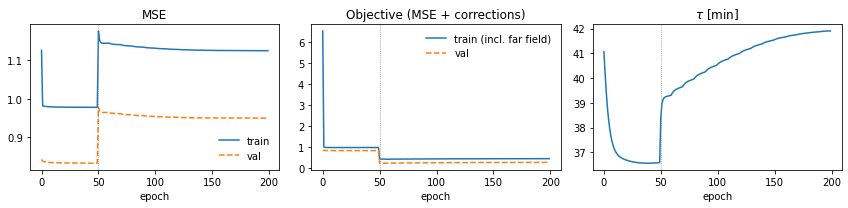

In [85]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(hist['train_mse'], label='train'); ax[0].plot(hist['val_mse'], '--', label='val'); ax[0].set_title('MSE')
ax[1].plot(hist['train_objective'], label='train (incl. far field)'); ax[1].plot(hist['val_objective'], '--', label='val')
ax[1].set_title('Objective (MSE + corrections)')
ax[2].plot(60 * np.array(hist['tau'])); ax[2].set_title(r'$\tau$ [min]')
for a in ax:
    a.set_xlabel('epoch'); a.axvline(warmup_epochs, color='grey', lw=0.8, ls=':')
ax[0].legend(frameon=False); ax[1].legend(frameon=False)
fig.tight_layout()

## Evaluation

In [86]:
# R^2 of the measured accelerations on masked validation nodes. Only comparable between runs
# trained with the SAME loss: the corrected loss deliberately does not minimise the MSE.
P, T = [], []
with torch.no_grad():
    for dp in val_data:
        pos, vel, edges, targ, w = tensors(dp)
        m = w.bool()
        P.append(model(pos, vel, edges)[m]); T.append(targ[m])
P, T = torch.cat(P).numpy(), torch.cat(T).numpy()
r2 = 1 - ((P - T) ** 2).mean(0) / T.var(0)
print(f"R^2: ax {r2[0]:.4f}, ay {r2[1]:.4f}, mean {r2.mean():.4f}")

R^2: ax 0.0662, ay 0.1544, mean 0.1103


### Corrected validation loss (comparison across models / losses)

Method.pdf Eq. (54) evaluated on held-out frames. To leading order it equals
$\langle(D_\theta - D_{\rm true})^2\rangle$ plus a constant that does not depend on the model, so lower is better,
provided every model is scored with the **same** $\sigma^2$ and $\Lambda$ (here this run's final values) on the
same frames. `load_old_sg_model` wraps a model saved by `old_SGonly/torch_notebook_SG_MDCK.ipynb`
(`save_model` → `.pt` + `_norm.json`) so it is scored with its physical drag (no $\Phi_{SG}$), in this dataset's normalisation.

In [87]:
import json

class _Rescaled(nn.Module):
    # f_new(r_new) = (y_old / y_new) * f_old(r_new * r_std_new / r_std_old)
    def __init__(self, net, r_scale, f_scale):
        super().__init__(); self.net, self.r_scale, self.f_scale = net, r_scale, f_scale
    def forward(self, r):
        return self.f_scale * self.net(r * self.r_scale)

def load_old_sg_model(pt_path, norm_json_path, norm_new, hidden_dim=64):
    sd = torch.load(pt_path, map_location='cpu')
    old_norm = json.load(open(norm_json_path))
    y_old = float(np.asarray(old_norm['y_std']).flat[0]); r_old = float(old_norm['r_std'])
    m = ForceGNN(hidden_dim, tau_init=float(sd['tau_raw']))
    m.interaction_net.load_state_dict({k.split('interaction_net.')[1]: v for k, v in sd.items() if k.startswith('interaction_net.')})
    m.set_normalisation(norm_new)
    m.interaction_net = _Rescaled(m.interaction_net, norm_new['r_std'] / r_old, y_old / norm_new['y_std'])
    return m

sigma2_ref = hist['sigma2'][-1]
noise_ref = dict(noise, correct=True)          # always include V_loc when scoring
score = dataset_terms(model, val_data, sigma2_ref, noise_ref, with_loc=True)
print(f"This model: corrected val loss {score['objective']:.5f} (mse {score['mse']:.5f}, dyn {score['dyn']:.5f}, loc {score['loc']:.5f})")

# old = load_old_sg_model(datasave + "<old_name>.pt", datasave + "<old_name>_norm.json", norm)
# s_old = dataset_terms(old, val_data, sigma2_ref, noise_ref, with_loc=True)
# print(f"Old SG model: corrected val loss {s_old['objective']:.5f} (mse {s_old['mse']:.5f})")

This model: corrected val loss 0.12075 (mse 0.95038, dyn -0.67873, loc 0.15090)


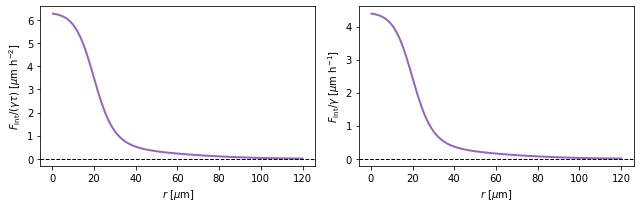

In [88]:
r_arr = np.linspace(0.3, r_cut, 200)
F = get_forces(model, r_arr)
tau_h = model.tau.item()
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(r_arr, F, color='tab:purple', lw=2); ax[0].set_ylabel(r'$F_{\rm int}/(\gamma\tau)$ [$\mu$m h$^{-2}$]')
ax[1].plot(r_arr, tau_h * F, color='tab:purple', lw=2); ax[1].set_ylabel(r'$F_{\rm int}/\gamma$ [$\mu$m h$^{-1}$]')
for a in ax:
    a.axhline(0, color='k', ls='--', lw=1); a.set_xlabel(r'$r$ [$\mu$m]')
fig.tight_layout()

## Compare two saved models: $\tau$, interaction force, noise magnitude

Loads the models listed in `compare`. Files saved by this notebook carry their own normalisation and noise estimates,
which are used directly. Files from `torch_notebook_NewLoss_MDCK.ipynb` hold only the weights (`interaction_net.*`,
`log_tau_raw`), so they are read with **this notebook's `norm`** and $\sigma^2$ is re-estimated; that is only right if the
Data cell uses the same settings as those runs (same CSV and frame window, `r_cut`, `edge_margin`,
S-G window/degree/shift, gap-aware derivatives, microns).

For those older files the noise magnitude is re-estimated from each model's final residual on the training frames (Method.pdf Eq. 55), both
without and with the localization-noise term $V_{\rm loc}$ (using $\hat\Lambda$), and converted to physical units:
$\sigma^2$ in µm² h⁻³ (for $\dot v = D + \sigma\xi$). The training runs used a momentum-averaged $\sigma^2$, so these
re-estimates can differ slightly from the value the run ended with.

This notebook: r_std = 28.4800 um, y_std = 9.7104 um/h^2, Lambda_hat = 0.40083 um^2


,tau [h],tau [min],"sigma^2, no V_loc [um^2 h^-3]","sigma^2, with V_loc [um^2 h^-3]","sigma, no V_loc","sigma, with V_loc",y_std used,noise values
model,,,,,,,,
MeasLocCorr Stem,0.6984,41.9063,82.8459,71.7035,9.1020,8.4678,9.7104,saved
MeasLocCorr Mese,0.7063,42.3755,155.3457,135.0848,12.4638,11.6226,13.1623,saved


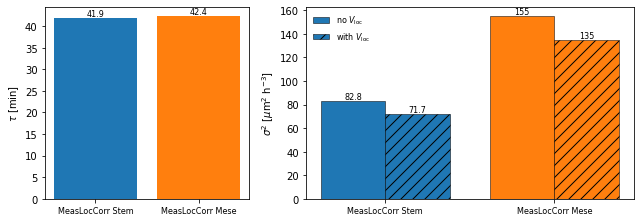

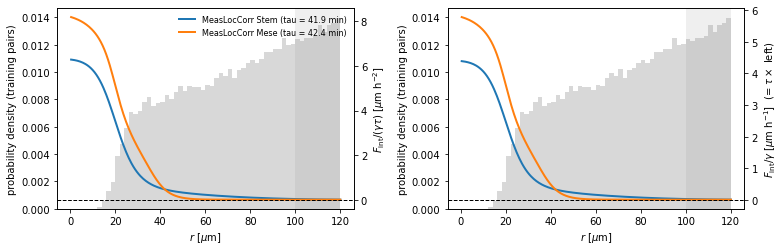

In [89]:
import pandas as pd

compare = {
    'MeasLocCorr Stem':  "model_20260515_wt_mdck_65hr_postHGF_s55_Tracks_MeasLocCorrFalse_tauinit0.7_sgParams_w7_p3_First80.pt",
    'MeasLocCorr Mese': "model_20260515_wt_mdck_65hr_postHGF_s55_Tracks_MeasLocCorrFalse_tauinit0.7_sgParams_w7_p3.pt",
}


def load_saved_model(path):
    # Returns (model, saved dict or None). Files saved by this notebook carry their own normalisation
    # and noise estimates; bare state dicts (older notebook) are read with this notebook's `norm`.
    sd = torch.load(path, map_location='cpu')
    saved = sd if 'state_dict' in sd else None
    if saved is not None:
        sd = saved['state_dict']
    sd = {('log_tau' if k == 'log_tau_raw' else k): v for k, v in sd.items()}
    m = ForceGNN(hidden_dim=(saved or {}).get('settings', {}).get('hidden_dim', hidden_dim))
    m.load_state_dict(sd)
    m.set_normalisation(saved['norm'] if saved is not None and 'norm' in saved else norm)
    return m, saved


cmp_models, rows = {}, []
for label, fname in compare.items():
    m, saved = load_saved_model(os.path.join(datasave, fname))
    cmp_models[label] = m
    if saved is not None and 'noise' in saved:
        s2_off, s2_on = saved['noise']['sigma2_no_Vloc'], saved['noise']['sigma2_with_Vloc']
        source = 'saved'
    else:                                   # re-estimate on this notebook's training frames
        y2 = norm['y_std'] ** 2
        s2_off = estimate_sigma2(m, train_data, dict(noise, correct=False)) * y2
        s2_on = estimate_sigma2(m, train_data, dict(noise, correct=True)) * y2
        source = 're-estimated (norm from this notebook)'
    rows.append({'model': label,
                 'tau [h]': m.tau.item(), 'tau [min]': 60 * m.tau.item(),
                 'sigma^2, no V_loc [um^2 h^-3]': s2_off,
                 'sigma^2, with V_loc [um^2 h^-3]': s2_on,
                 'sigma, no V_loc': np.sqrt(s2_off) if s2_off > 0 else np.nan,
                 'sigma, with V_loc': np.sqrt(s2_on) if s2_on > 0 else np.nan,
                 'y_std used': m.y_std, 'noise values': source})
print(f"This notebook: r_std = {norm['r_std']:.4f} um, y_std = {norm['y_std']:.4f} um/h^2, Lambda_hat = {Lambda_hat:.5f} um^2")
display(pd.DataFrame(rows).set_index('model').round(4))

# ---- tau and sigma^2 bar charts ----
labels = list(cmp_models)
colors = [f"C{k}" for k in range(len(labels))]
df = pd.DataFrame(rows).set_index('model')
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2), gridspec_kw=dict(width_ratios=[1, 1.6]))
ax[0].bar(labels, df['tau [min]'], color=colors)
ax[0].set_ylabel(r'$\tau$ [min]')
for k, v in enumerate(df['tau [min]']):
    ax[0].text(k, v, f"{v:.1f}", ha='center', va='bottom', fontsize=8)
x, wbar = np.arange(len(labels)), 0.38
for off, col, hatch, name in ((-wbar / 2, 'sigma^2, no V_loc [um^2 h^-3]', '', r'no $V_{\rm loc}$'),
                              (+wbar / 2, 'sigma^2, with V_loc [um^2 h^-3]', '//', r'with $V_{\rm loc}$')):
    b = ax[1].bar(x + off, df[col], wbar, color=colors, hatch=hatch, edgecolor='k', lw=0.5, label=name)
    for xi, v in zip(x + off, df[col]):
        ax[1].text(xi, v, f"{v:.3g}", ha='center', va='bottom', fontsize=8)
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_ylabel(r'$\sigma^2$ [$\mu$m$^2$ h$^{-3}$]')
ax[1].legend(frameon=False, fontsize=8)
for a in ax:
    a.tick_params(axis='x', labelsize=8)
fig.tight_layout()

# ---- interaction force on top of the distribution of training pair distances ----
# Distances of edges in the training frames whose target node enters the loss (the pairs whose
# forces are fitted), in um; each unordered pair can appear twice (once per direction).
r_seen = np.concatenate([dp['edge_feat'][dp['mask'][dp['edges'][1]] > 0, 0] * norm['r_std']
                         for dp in train_data])
r_arr = np.linspace(0.3, r_cut, 300)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
twins = []
for a, scaled, ylabel in ((ax[0], False, r'$F_{\rm int}/(\gamma\tau)$ [$\mu$m h$^{-2}$]'),
                          (ax[1], True, r'$F_{\rm int}/\gamma$ [$\mu$m h$^{-1}$]  (= $\tau\times$ left)')):
    a.hist(r_seen, bins=60, range=(0, r_cut), density=True, color='grey', alpha=0.3, lw=0)
    a.set_ylabel('probability density (training pairs)')
    a.set_xlabel(r'$r$ [$\mu$m]')
    if far_field['reg'] != 0:
        a.axvspan(far_field['r_min'], far_field['r_max'], color='grey', alpha=0.12, lw=0)
    a2 = a.twinx()
    twins.append(a2)
    for label, m, col in zip(labels, cmp_models.values(), colors):
        F = get_forces(m, r_arr) * (m.tau.item() if scaled else 1.0)
        a2.plot(r_arr, F, lw=2, color=col, label=f"{label} (tau = {60 * m.tau.item():.1f} min)")
    a2.axhline(0, color='k', ls='--', lw=1)
    a2.set_ylabel(ylabel)
twins[0].legend(frameon=False, fontsize=8)
fig.tight_layout()